CARGAR LA BASE DE DATOS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../data/processed/base_VAR_Ecuador.csv")

df.head()

,Año,PIB,Inflacion,Desempleo
0,2007,1.902429,2.276185,3.142
1,2008,6.564921,8.400096,3.917
2,2009,1.091013,5.159968,4.608
3,2010,4.029138,3.554377,4.088
4,2011,8.481477,4.474533,3.458


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Año        18 non-null     int64  
 1   PIB        18 non-null     float64
 2   Inflacion  18 non-null     float64
 3   Desempleo  18 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 708.0 bytes


In [ ]:
df.isnull().sum()

Año          0
PIB          0
Inflacion    0
Desempleo    0
dtype: int64

In [ ]:
df.describe().round(2)

,Año,PIB,Inflacion,Desempleo
count,18.00,18.00,18.00,18.00
mean,2015.50,2.88,2.69,3.87
std,5.34,4.49,2.29,0.73
min,2007.00,-9.25,-0.34,3.08
25%,2011.25,0.39,0.70,3.46
50%,2015.50,2.97,2.50,3.66
75%,2019.75,5.94,3.87,4.05
max,2024.00,9.42,8.40,6.12


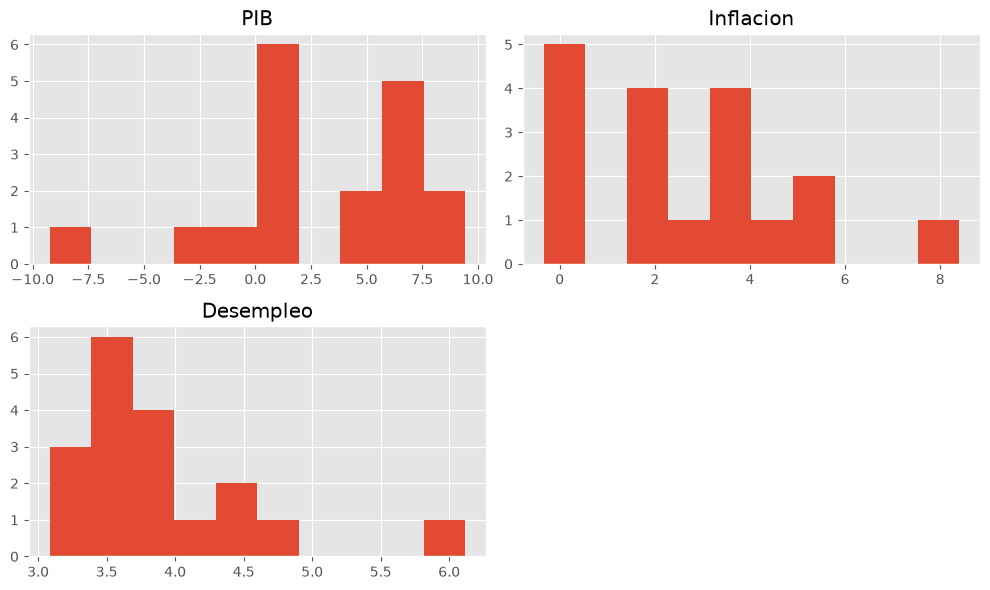

In [ ]:
df[["PIB","Inflacion","Desempleo"]].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

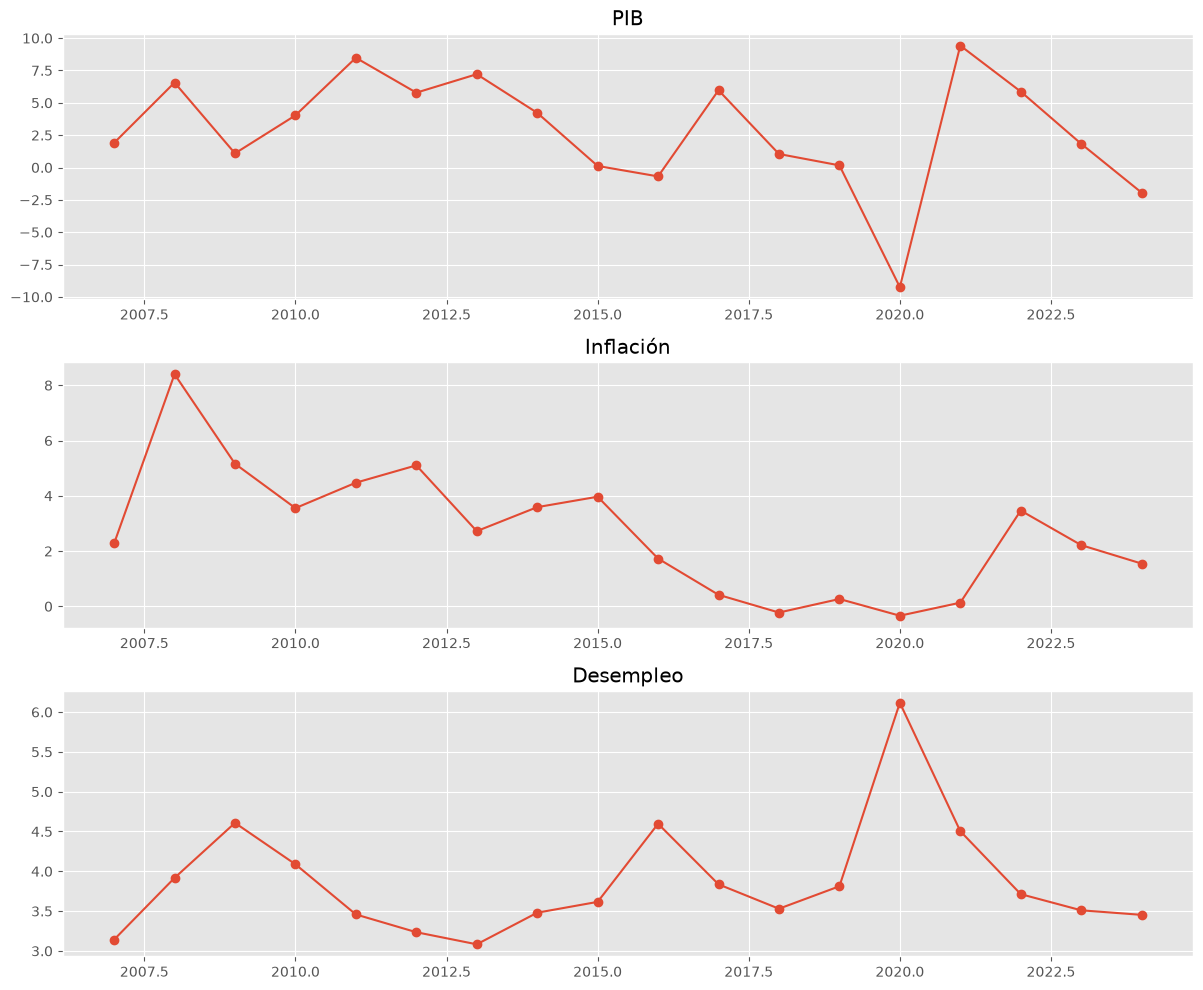

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(12,10))

ax[0].plot(df["Año"], df["PIB"], marker="o")
ax[0].set_title("PIB")

ax[1].plot(df["Año"], df["Inflacion"], marker="o")
ax[1].set_title("Inflación")

ax[2].plot(df["Año"], df["Desempleo"], marker="o")
ax[2].set_title("Desempleo")

plt.tight_layout()
plt.show()

ESTADISTICAS DESCRIPTIVAS

In [ ]:
import pandas as pd

# Cargar la base
df = pd.read_csv("../data/processed/base_VAR_Ecuador.csv")

tabla1 = df[["PIB","Inflacion","Desempleo"]].describe().round(3)

tabla1

,PIB,Inflacion,Desempleo
count,18.000,18.000,18.000
mean,2.880,2.692,3.872
std,4.493,2.293,0.726
min,-9.245,-0.339,3.083
25%,0.385,0.700,3.464
50%,2.966,2.499,3.665
75%,5.945,3.872,4.045
max,9.422,8.400,6.116


In [ ]:
tabla1.to_csv("../outputs/tables/tabla1_estadisticos_descriptivos.csv")

MATRIZ DE CORRELACION

In [ ]:
correlacion = df[["PIB","Inflacion","Desempleo"]].corr().round(3)

correlacion

,PIB,Inflacion,Desempleo
PIB,1.000,0.397,-0.553
Inflacion,0.397,1.000,-0.275
Desempleo,-0.553,-0.275,1.000


In [ ]:
correlacion.to_csv("../outputs/tables/tabla2_correlacion.csv")

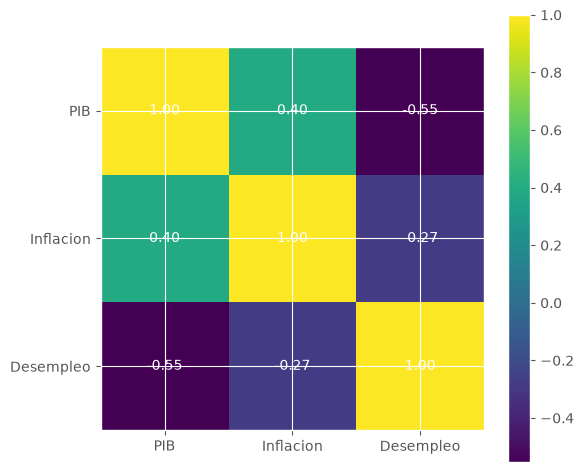

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

corr = df[["PIB","Inflacion","Desempleo"]].corr()

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j,
                i,
                f"{corr.iloc[i,j]:.2f}",
                ha="center",
                va="center",
                color="white")

plt.colorbar(im)

plt.tight_layout()

plt.savefig("../outputs/figures/Figura2_correlacion.png",
            dpi=300)

plt.show()